# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Gede Pradnyananda
- Email: gedenanda4444@gmail.com
- Id Dicoding: gede_pradnyanadna

## Persiapan

### Menyiapkan library yang dibutuhkan

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import PartialDependenceDisplay
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.utils import resample



### Menyiapkan df yang akan diguankan

## Data Understanding

In [28]:
df = pd.read_csv('data.csv', sep=';')
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [12]:
df.isna().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


Dataset bersih dari nilai Nan. Tetapi masalahnya adalah data kategorikal masih bertipe int. Oleh sebab itu, saya mengembalikan ke tipe kategorikal berdasarkan pedoman README.md yang diberikan. 

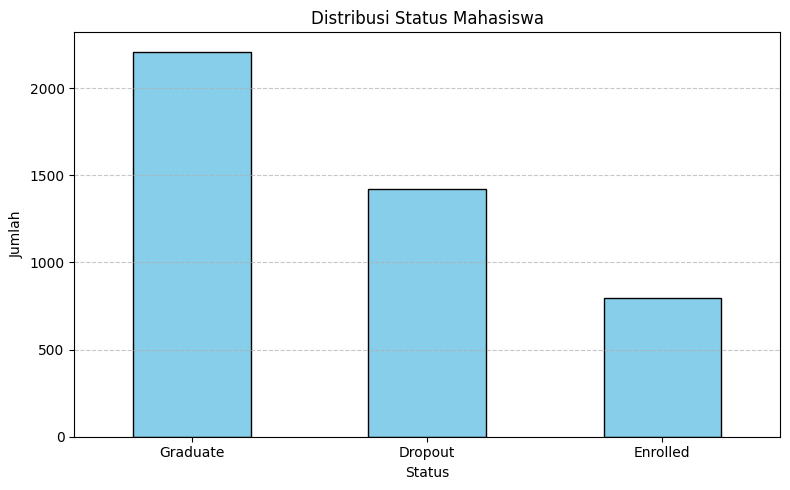

In [34]:
# Plot histogram distribusi status
plt.figure(figsize=(8, 5))
df['Status'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Distribusi Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## df Preparation / Preprocessing

### Konversi ke kategorikal

In [29]:

marital_status_map = {
    1: 'single', 2: 'married', 3: 'widower', 4: 'divorced', 5: 'facto union', 6: 'legally separated'
}

application_mode_map = {
    1: '1st phase - general contingent', 2: 'Ordinance No. 612/93', 5: '1st phase - special contingent (Azores Island)',
    7: 'Holders of other higher courses', 10: 'Ordinance No. 854-B/99', 15: 'International student (bachelor)',
    16: '1st phase - special contingent (Madeira Island)', 17: '2nd phase - general contingent',
    18: '3rd phase - general contingent', 26: 'Ordinance No. 533-A/99, item b2)', 27: 'Ordinance No. 533-A/99, item b3',
    39: 'Over 23 years old', 42: 'Transfer', 43: 'Change of course', 44: 'Technological specialization diploma holders',
    51: 'Change of institution/course', 53: 'Short cycle diploma holders', 57: 'Change of institution/course (International)'
}

course_map = {
    33: 'Biofuel Production Technologies', 171: 'Animation and Multimedia Design', 8014: 'Social Service (evening attendance)',
    9003: 'Agronomy', 9070: 'Communication Design', 9085: 'Veterinary Nursing', 9119: 'Informatics Engineering',
    9130: 'Equinculture', 9147: 'Management', 9238: 'Social Service', 9254: 'Tourism', 9500: 'Nursing',
    9556: 'Oral Hygiene', 9670: 'Advertising and Marketing Management', 9773: 'Journalism and Communication',
    9853: 'Basic Education', 9991: 'Management (evening attendance)'
}

binary_map = {1: 'yes', 0: 'no'}
gender_map = {1: 'male', 0: 'female'}
daytime_evening_map = {1: 'daytime', 0: 'evening'}

# Mapping untuk 'Previous qualification'
previous_qualification_map = {
    1: 'Secondary education',
    2: "Higher education - bachelor's degree",
    3: 'Higher education - degree',
    4: "Higher education - master's",
    5: 'Higher education - doctorate',
    6: 'Frequency of higher education',
    9: '12th year of schooling - not completed',
    10: '11th year of schooling - not completed',
    12: 'Other - 11th year of schooling',
    14: '10th year of schooling',
    15: '10th year of schooling - not completed',
    19: 'Basic education 3rd cycle (9th/10th/11th year) or equiv.',
    38: 'Basic education 2nd cycle (6th/7th/8th year) or equiv.',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    42: 'Professional higher technical course',
    43: 'Higher education - master (2nd cycle)'
}

# Mapping untuk 'Mother\'s qualification'
mother_qualification_map = {
    1: 'Secondary Education - 12th Year of Schooling or Eq.',
    2: "Higher Education - Bachelor's Degree",
    3: 'Higher Education - Degree',
    4: "Higher Education - Master's",
    5: 'Higher Education - Doctorate',
    6: 'Frequency of Higher Education',
    9: '12th Year of Schooling - Not Completed',
    10: '11th Year of Schooling - Not Completed',
    11: '7th Year (Old)',
    12: 'Other - 11th Year of Schooling',
    14: '10th Year of Schooling',
    18: 'General commerce course',
    19: 'Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',
    22: 'Technical-professional course',
    26: '7th year of schooling',
    27: '2nd cycle of the general high school course',
    29: '9th Year of Schooling - Not Completed',
    30: '8th year of schooling',
    34: 'Unknown',
    35: "Can't read or write",
    36: 'Can read without having a 4th year of schooling',
    37: 'Basic education 1st cycle (4th/5th year) or equiv.',
    38: 'Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    41: 'Specialized higher studies course',
    42: 'Professional higher technical course',
    43: 'Higher Education - Master (2nd cycle)',
    44: 'Higher Education - Doctorate (3rd cycle)'
}

# Mapping untuk 'Father\'s qualification'
father_qualification_map = {
    1: 'Secondary Education - 12th Year of Schooling or Eq.',
    2: "Higher Education - Bachelor's Degree",
    3: 'Higher Education - Degree',
    4: "Higher Education - Master's",
    5: 'Higher Education - Doctorate',
    6: 'Frequency of Higher Education',
    9: '12th Year of Schooling - Not Completed',
    10: '11th Year of Schooling - Not Completed',
    11: '7th Year (Old)',
    12: 'Other - 11th Year of Schooling',
    13: '2nd year complementary high school course',
    14: '10th Year of Schooling',
    18: 'General commerce course',
    19: 'Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',
    20: 'Complementary High School Course',
    22: 'Technical-professional course',
    25: 'Complementary High School Course - not concluded',
    26: '7th year of schooling',
    27: '2nd cycle of the general high school course',
    29: '9th Year of Schooling - Not Completed',
    30: '8th year of schooling',
    31: 'General Course of Administration and Commerce',
    33: 'Supplementary Accounting and Administration',
    34: 'Unknown',
    35: "Can't read or write",
    36: 'Can read without having a 4th year of schooling',
    37: 'Basic education 1st cycle (4th/5th year) or equiv.',
    38: 'Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    41: 'Specialized higher studies course',
    42: 'Professional higher technical course',
    43: 'Higher Education - Master (2nd cycle)',
    44: 'Higher Education - Doctorate (3rd cycle)'
}
# Mapping untuk 'Mother\'s occupation'
mother_occupation_map = {
    0: 'Student',
    1: 'Legislative/Executive Managers',
    2: 'Scientific Specialists',
    3: 'Intermediate Level Technicians',
    4: 'Administrative staff',
    5: 'Services/Security/Sellers',
    6: 'Agriculture/Fisheries Workers',
    7: 'Industry/Construction Workers',
    8: 'Machine Operators',
    9: 'Unskilled Workers',
    10: 'Armed Forces Professions',
    90: 'Other Situation',
    99: '(blank)',
    122: 'Health professionals',
    123: 'Teachers',
    125: 'ICT Specialists',
    131: 'Science/Engineering Technicians',
    132: 'Health Technicians',
    134: 'Legal/Social/Cultural Technicians',
    141: 'Office workers / data operators',
    143: 'Accounting/Financial/Registry Operators',
    144: 'Other Admin Support',
    151: 'Personal service workers',
    152: 'Sellers',
    153: 'Personal care workers',
    171: 'Construction workers (non-electricians)',
    173: 'Artisans/Precision instrument workers',
    175: 'Food/Wood/Clothing workers',
    191: 'Cleaning workers',
    192: 'Unskilled agriculture/forestry workers',
    193: 'Unskilled industrial/construction workers',
    194: 'Meal preparation assistants'
}

# Mapping untuk 'Father\'s occupation'
father_occupation_map = {
    0: 'Student',
    1: 'Legislative/Executive Managers',
    2: 'Scientific Specialists',
    3: 'Intermediate Level Technicians',
    4: 'Administrative staff',
    5: 'Services/Security/Sellers',
    6: 'Agriculture/Fisheries Workers',
    7: 'Industry/Construction Workers',
    8: 'Machine Operators',
    9: 'Unskilled Workers',
    10: 'Armed Forces Professions',
    90: 'Other Situation',
    99: '(blank)',
    101: 'Armed Forces Officers',
    102: 'Armed Forces Sergeants',
    103: 'Other Armed Forces personnel',
    112: 'Admin/Commercial Service Directors',
    114: 'Hotel/Trade Service Directors',
    121: 'Physical Sciences/Engineering Specialists',
    122: 'Health professionals',
    123: 'Teachers',
    124: 'Finance/Admin/PR Specialists',
    131: 'Science/Engineering Technicians',
    132: 'Health Technicians',
    134: 'Legal/Social/Cultural Technicians',
    135: 'ICT Technicians',
    141: 'Office workers / data operators',
    143: 'Accounting/Financial/Registry Operators',
    144: 'Other Admin Support',
    151: 'Personal service workers',
    152: 'Sellers',
    153: 'Personal care workers',
    154: 'Security personnel',
    161: 'Market-oriented Farmers',
    163: 'Subsistence farmers/hunters/fishermen',
    171: 'Construction workers (non-electricians)',
    172: 'Metalworkers',
    174: 'Electricians/Electronics Workers',
    175: 'Food/Wood/Clothing workers',
    181: 'Fixed plant operators',
    182: 'Assembly workers',
    183: 'Vehicle drivers/mobile equipment',
    192: 'Unskilled agriculture/forestry workers',
    193: 'Unskilled industrial/construction workers',
    194: 'Meal preparation assistants',
    195: 'Street vendors/service providers'
}
nationality_map = {
    1: "Portuguese", 2: "German", 6: "Spanish", 11: "Italian",
    13: "Dutch", 14: "English", 17: "Lithuanian", 21: "Angolan",
    22: "Cape Verdean", 24: "Guinean", 25: "Mozambican", 26: "Santomean",
    32: "Turkish", 41: "Brazilian", 62: "Romanian", 100: "Moldova (Republic of)",
    101: "Mexican", 103: "Ukrainian", 105: "Russian", 108: "Cuban", 109: "Colombian"
}

df['Nacionality'] = df['Nacionality'].map(nationality_map)
# Terapkan mapping ke DataFrame
df["Mothers_occupation"] = df["Mothers_occupation"].map(mother_occupation_map)
df["Fathers_occupation"] = df["Fathers_occupation"].map(father_occupation_map)

# Terapkan mapping ke DataFrame
df['Previous_qualification'] = df['Previous_qualification'].map(previous_qualification_map)
df["Mothers_qualification"] = df["Mothers_qualification"].map(mother_qualification_map)
df["Fathers_qualification"] = df["Fathers_qualification"].map(father_qualification_map)


# Terapkan konversi
df['Marital_status'] = df['Marital_status'].map(marital_status_map)
df['Application_mode'] = df['Application_mode'].map(application_mode_map)
df['Course'] = df['Course'].map(course_map)
df['Daytime_evening_attendance'] = df['Daytime_evening_attendance'].map(daytime_evening_map)
df['Displaced'] = df['Displaced'].map(binary_map)
df['Educational_special_needs'] = df['Educational_special_needs'].map(binary_map)
df['Debtor'] = df['Debtor'].map(binary_map)
df['Tuition_fees_up_to_date'] = df['Tuition_fees_up_to_date'].map(binary_map)
df['Gender'] = df['Gender'].map(gender_map)
df['Scholarship_holder'] = df['Scholarship_holder'].map(binary_map)
df['International'] = df['International'].map(binary_map)

# Simpan hasil konversi
df.to_csv("df_converted.csv", index=False, sep=';')

print("Konversi selesai. File disimpan sebagai df_converted.csv.")


Konversi selesai. File disimpan sebagai df_converted.csv.


In [36]:
data2 = pd.read_csv('df_converted.csv', sep=';')
print(data2['Status'].unique())


['Dropout' 'Graduate' 'Enrolled']


In [37]:
data2['Status'] = data2['Status'].str.strip().str.lower()
data2['Status'] = data2['Status'].apply(lambda x: 'Dropout' if x == 'dropout' else 'Non-Dropout')
print(data2['Status'].unique())

['Dropout' 'Non-Dropout']


In [51]:
data2['Status'].unique()

array(['Dropout', 'Non-Dropout'], dtype=object)

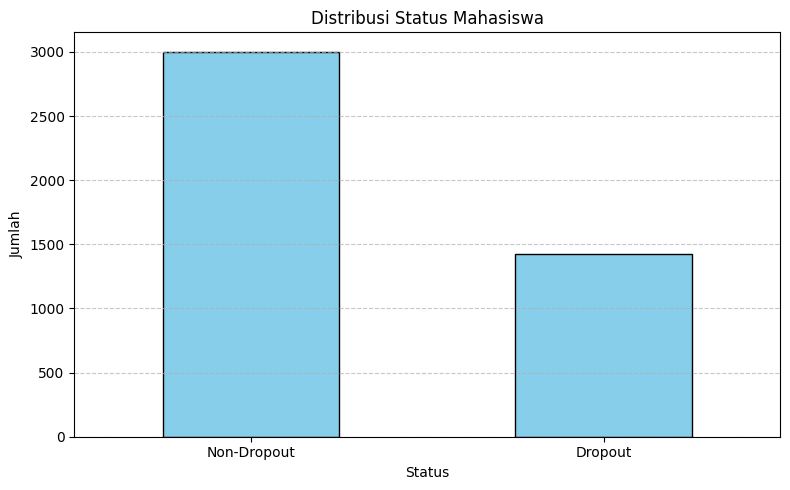

In [54]:
# Plot histogram distribusi status
plt.figure(figsize=(8, 5))
data2['Status'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Distribusi Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [38]:
data2.to_csv('df_converted.csv', index=False,sep=';')

In [43]:
data2 = pd.read_csv('df_converted.csv', sep=';')

### Visualisasi Kategorikal

In [49]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   object 
 1   Application_mode                              4424 non-null   object 
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   object 
 4   Daytime_evening_attendance                    4424 non-null   object 
 5   Previous_qualification                        4424 non-null   object 
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   object 
 8   Mothers_qualification                         4424 non-null   object 
 9   Fathers_qualification                         4424 non-null   o

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

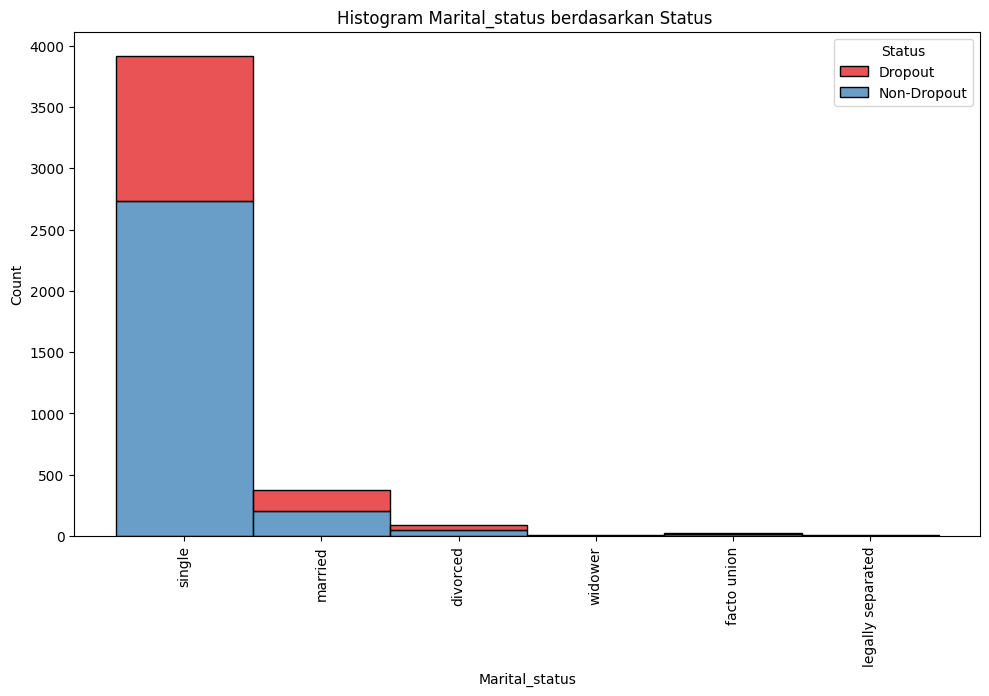

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

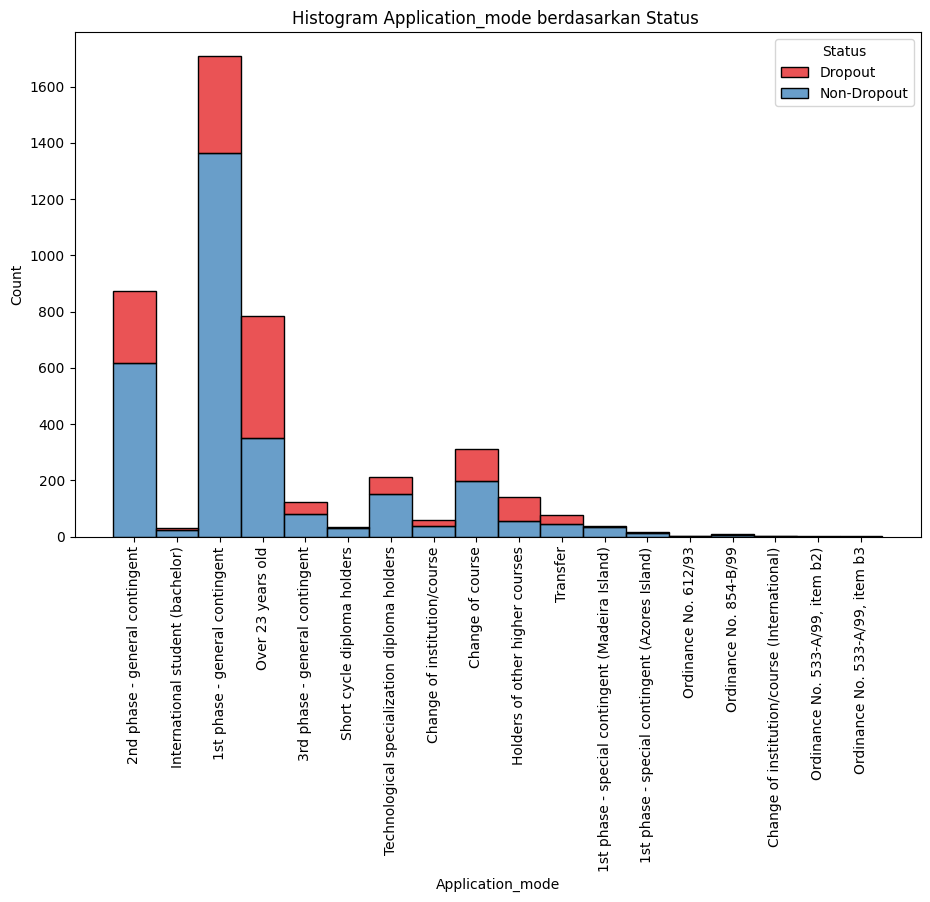

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

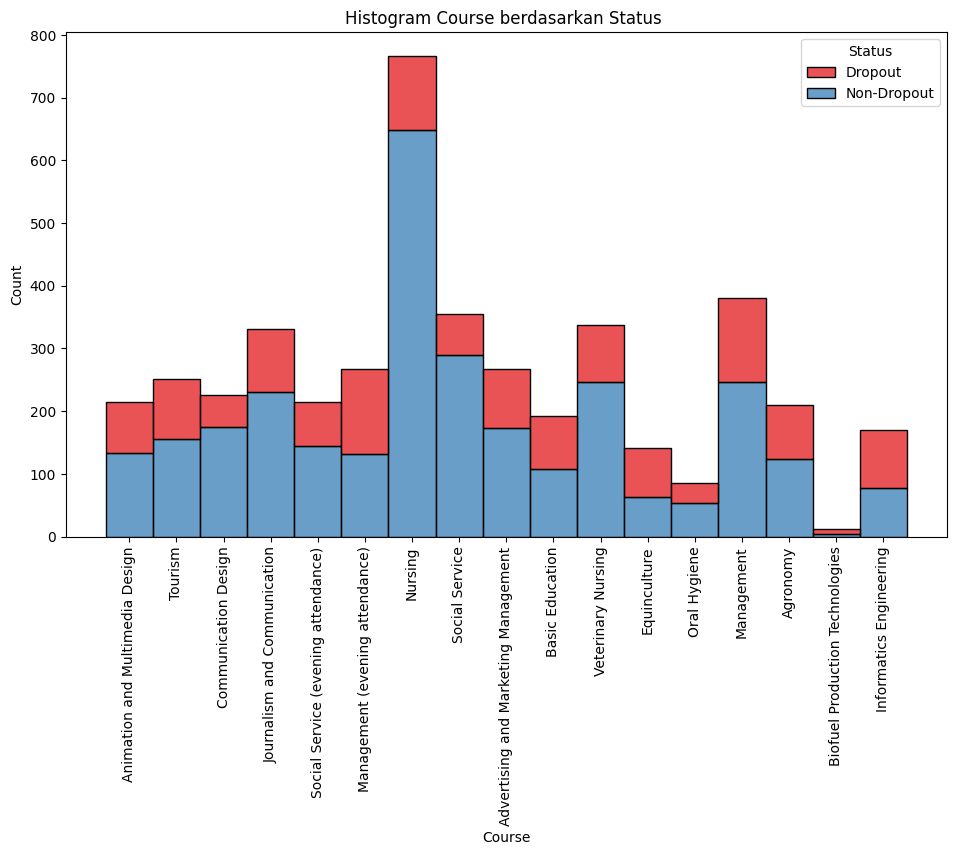

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

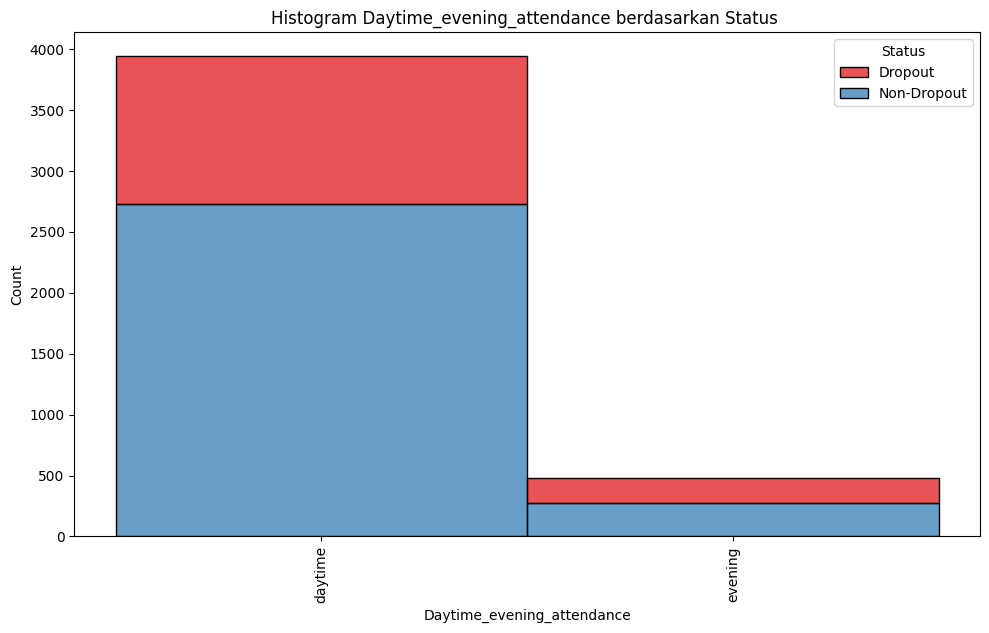

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

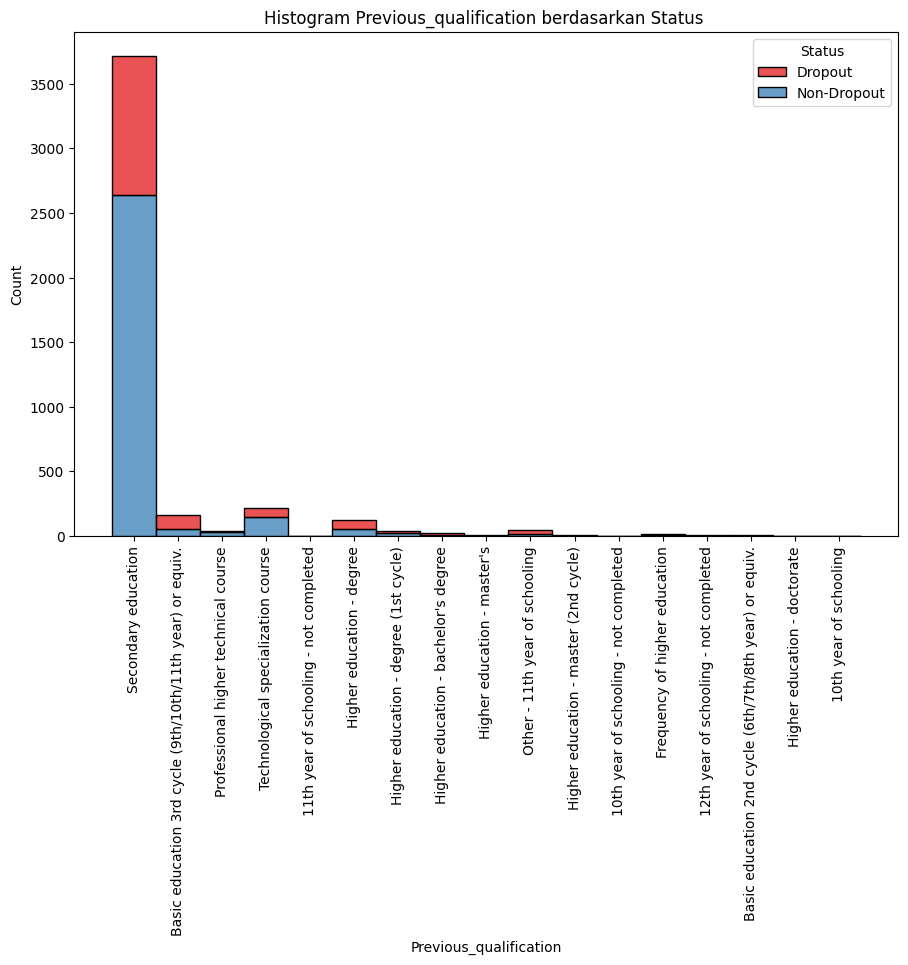

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

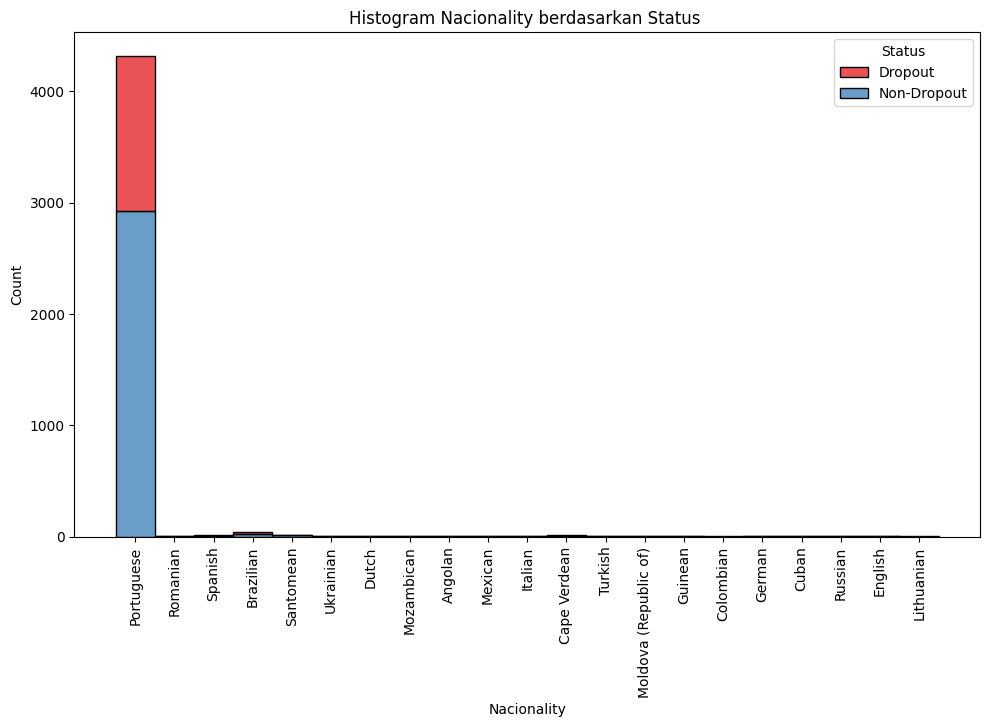

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

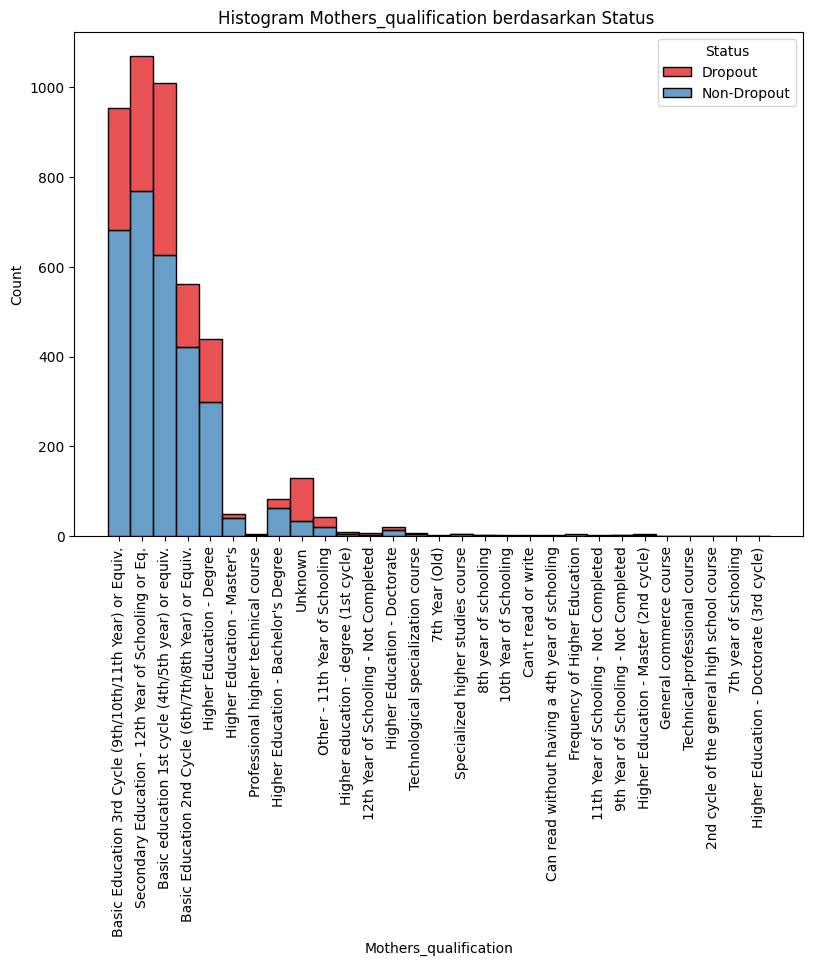

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

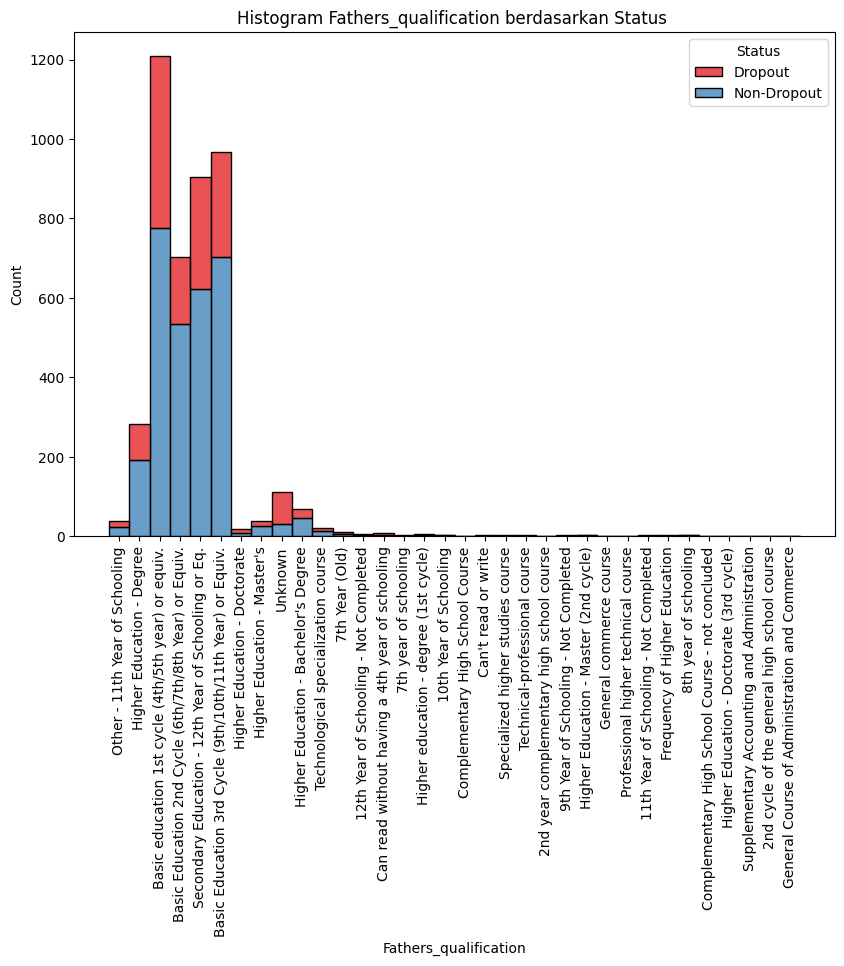

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

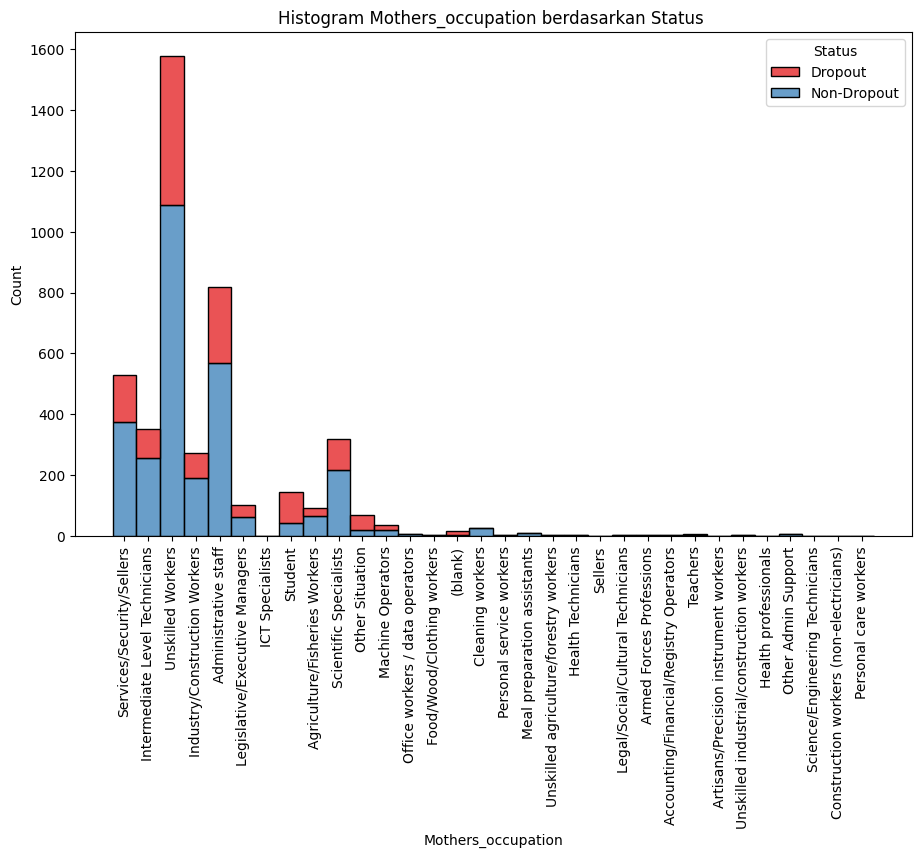

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

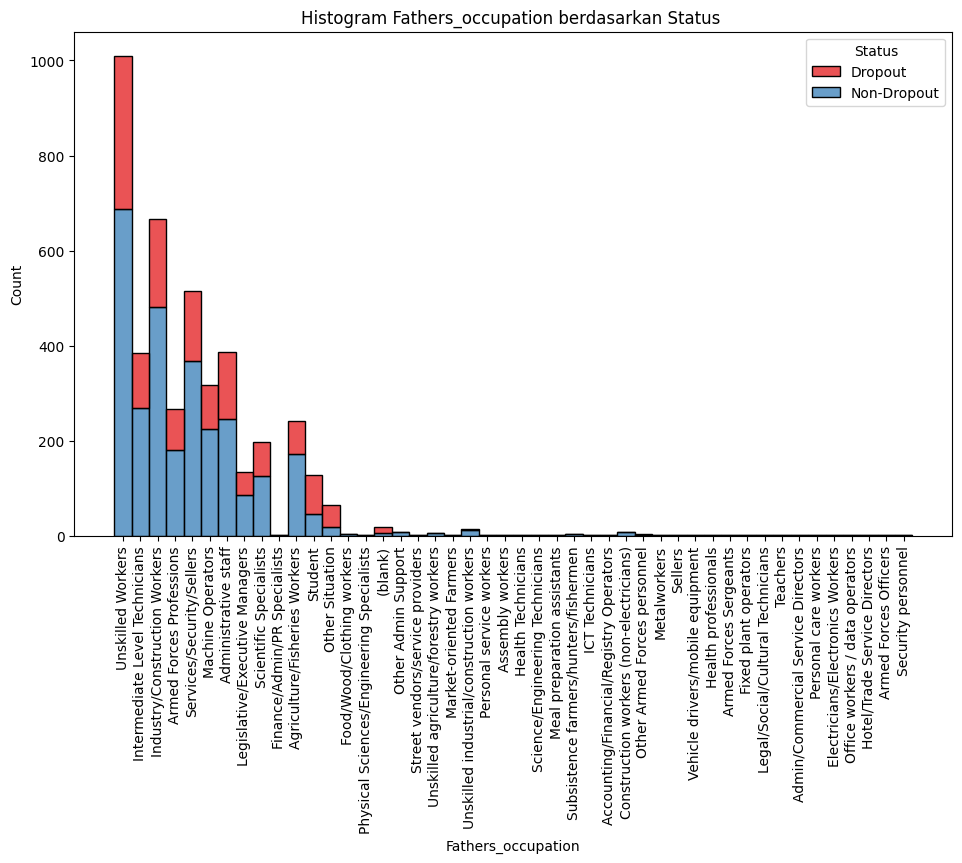

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

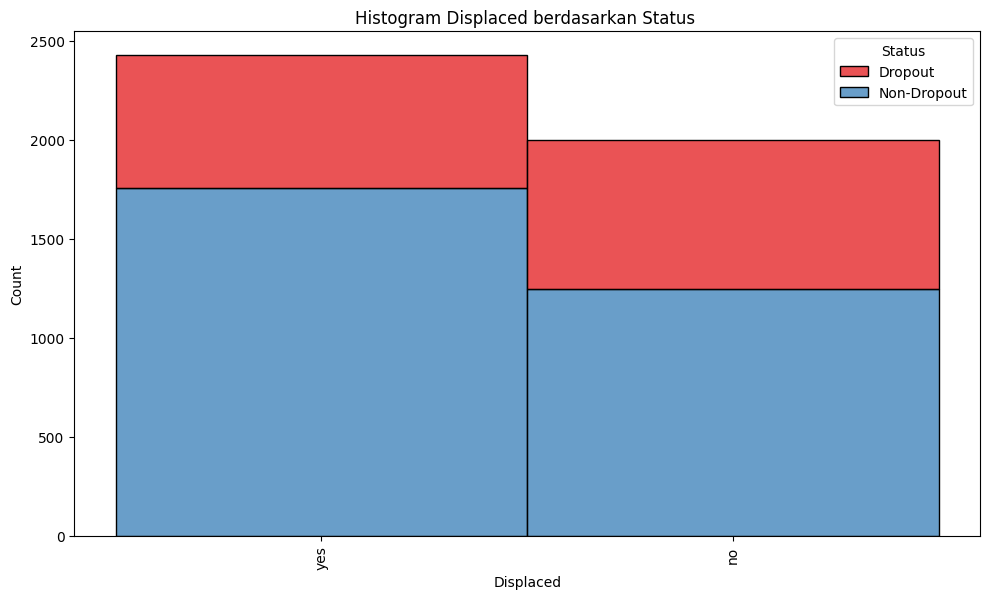

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

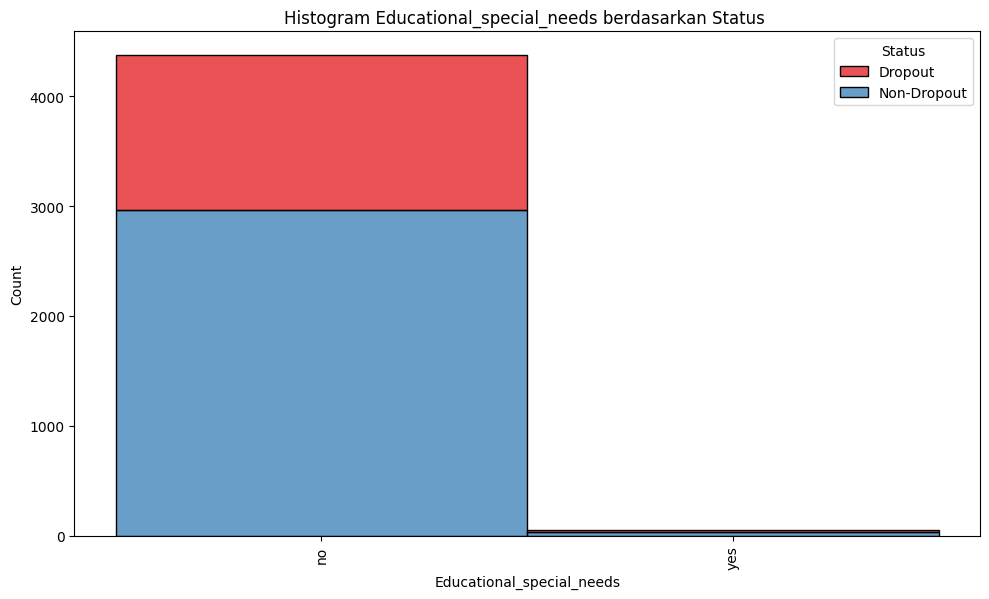

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

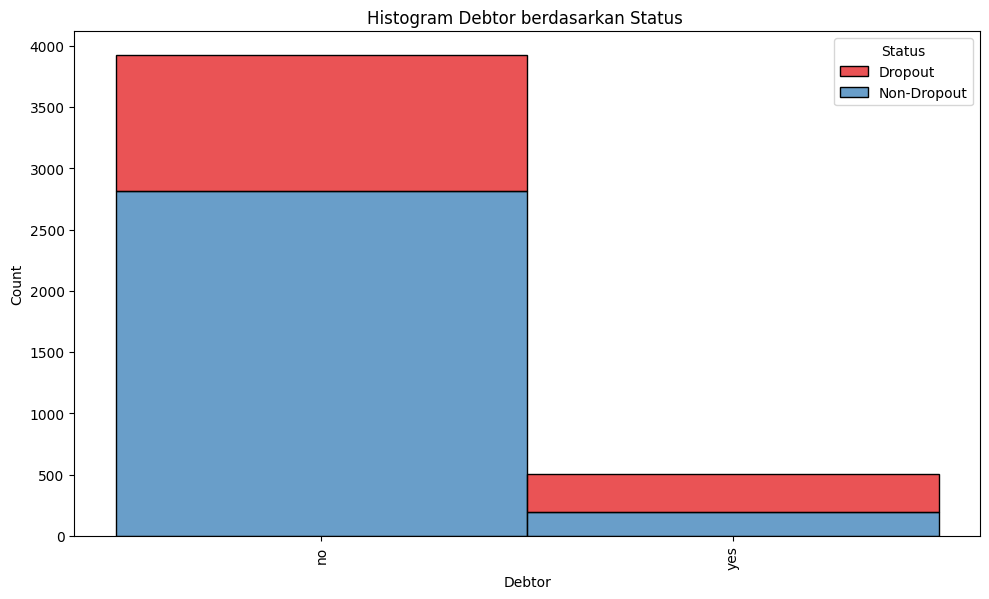

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

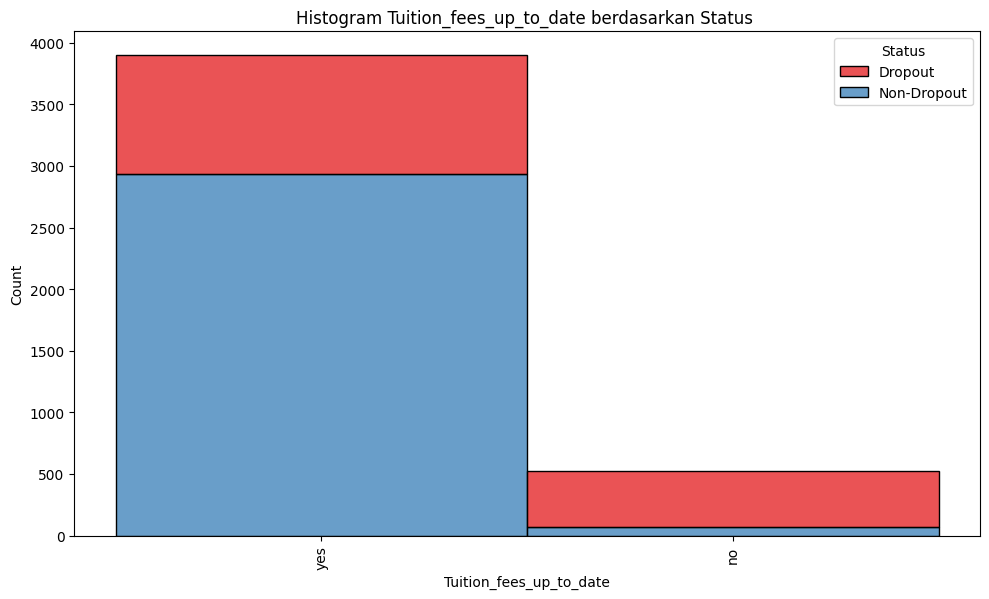

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

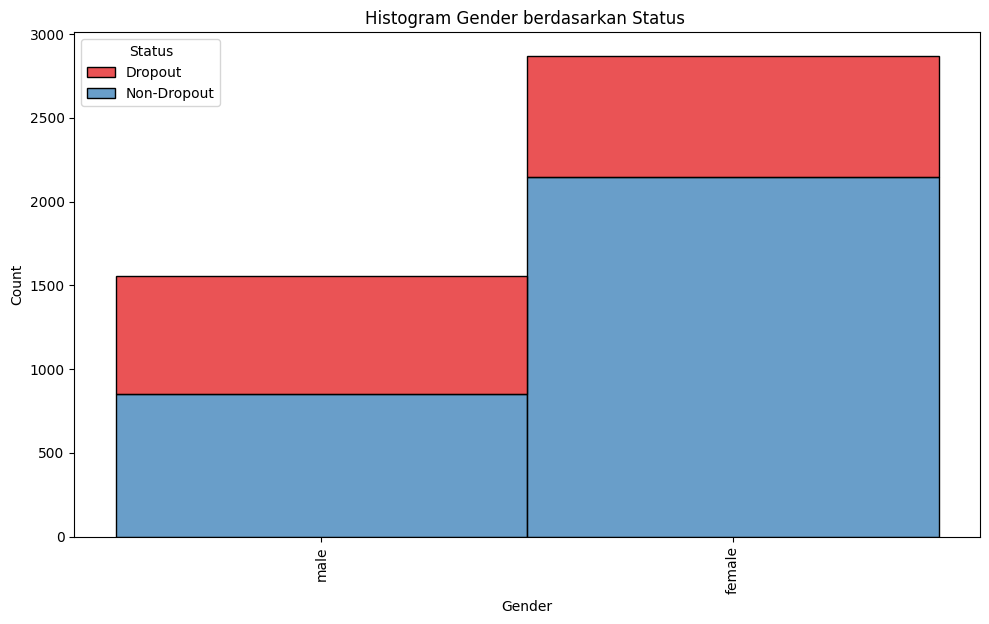

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

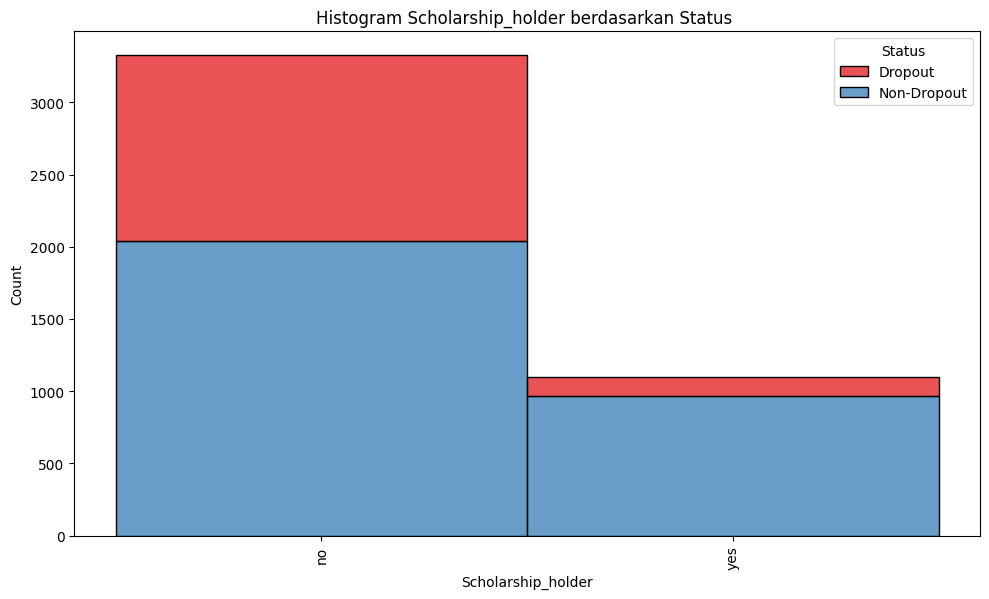

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarni

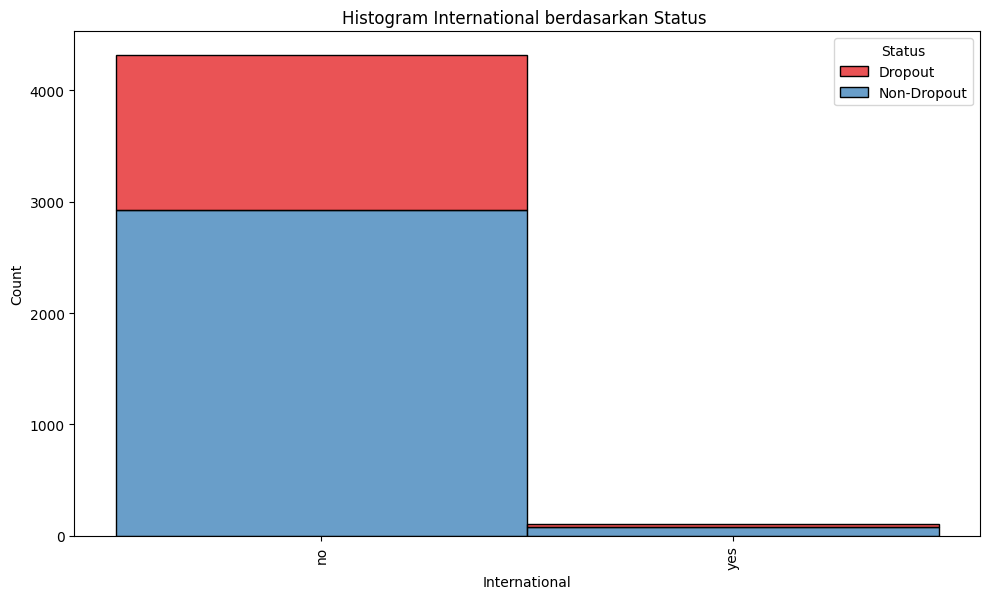

In [52]:
sus = data2.drop(columns='Status', axis=1)
sus = sus.select_dtypes(include='object')
sus = sus.columns
for i in sus:
        plt.figure(figsize=(10, 6))
        sns.histplot(
            data=data2,
            x=i,
            hue='Status',  
            multiple='stack',  
            kde=False,
            bins=30,
            palette='Set1'  
        )
        plt.title(f'Histogram {i} berdasarkan Status ')
        plt.xlabel(i)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.xticks(rotation=90)
        plt.show()

### Visualisasi Numerik

/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gede/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

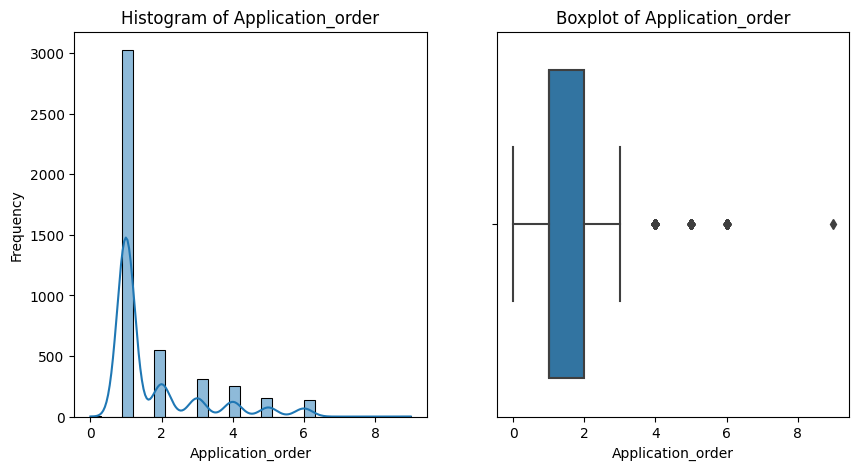

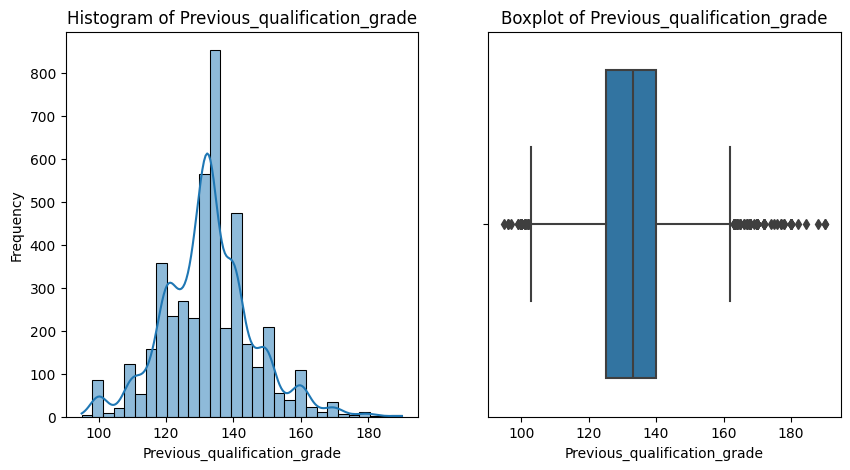

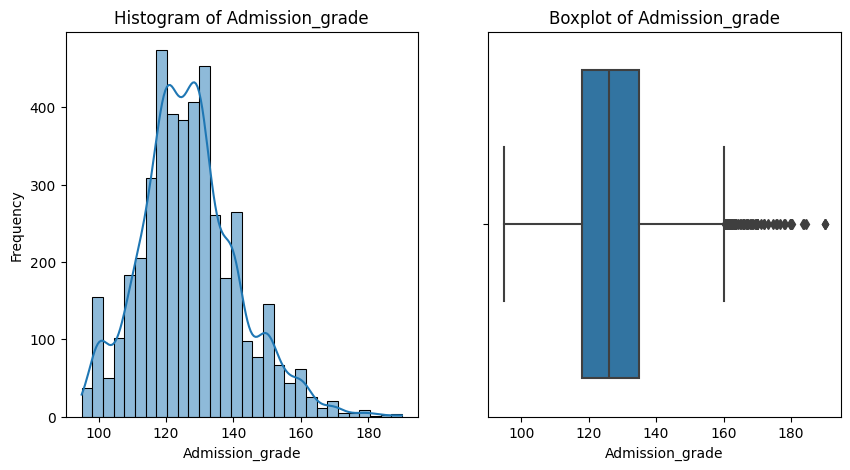

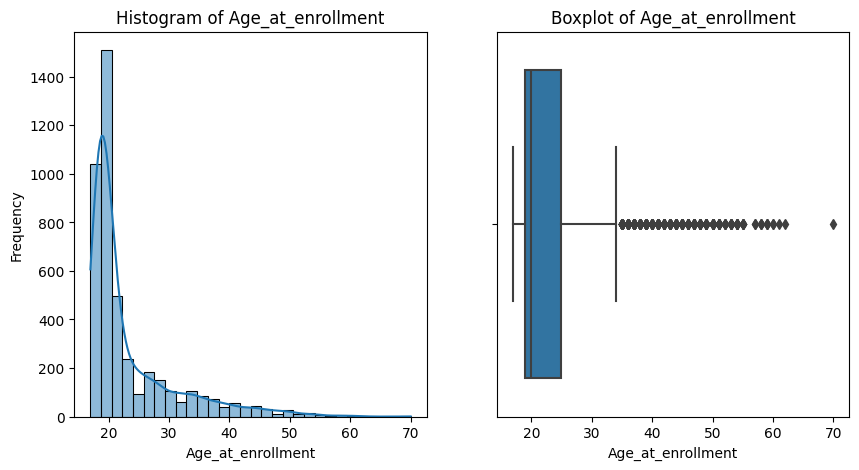

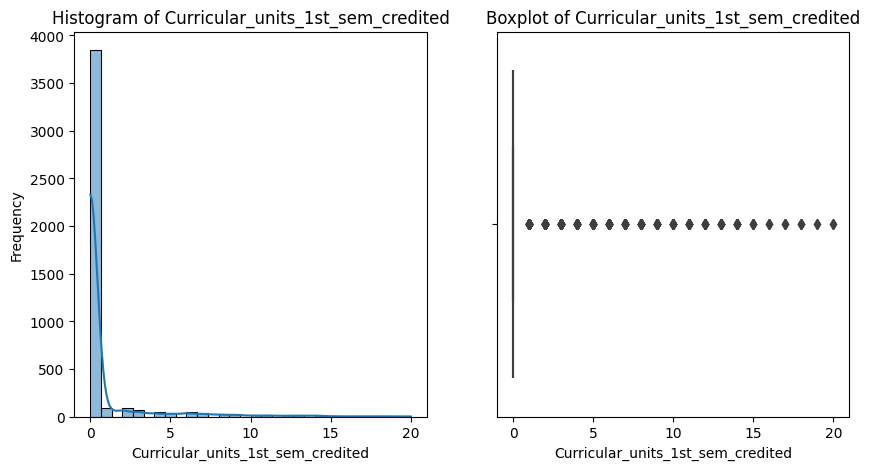

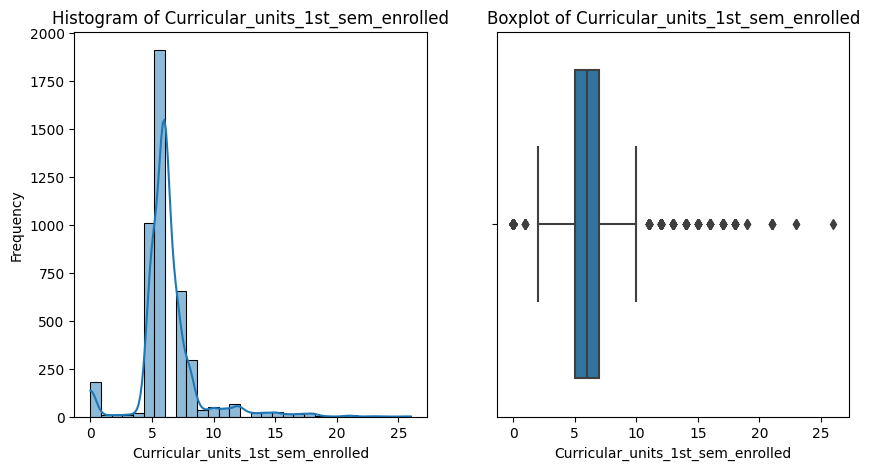

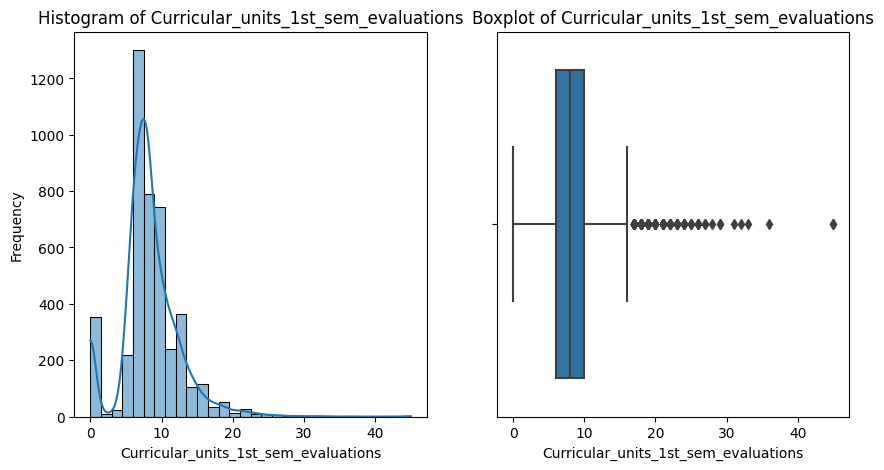

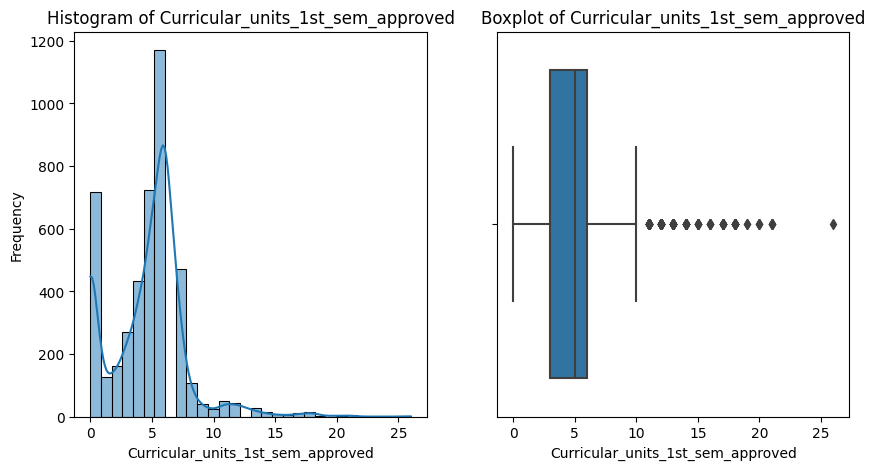

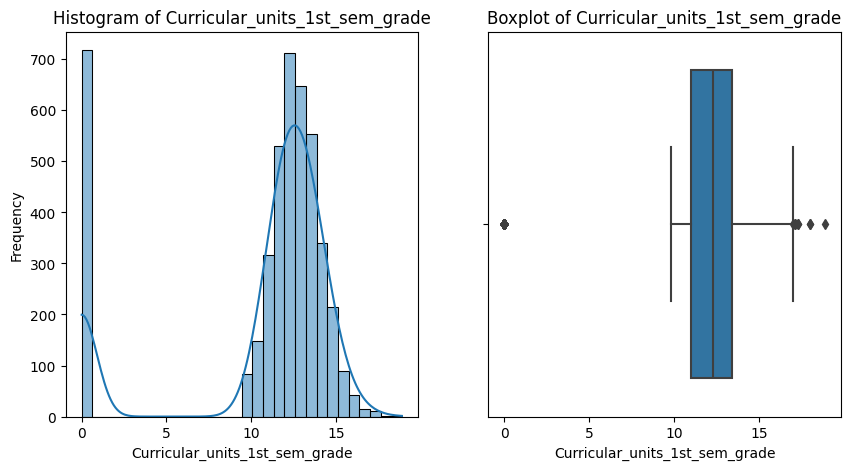

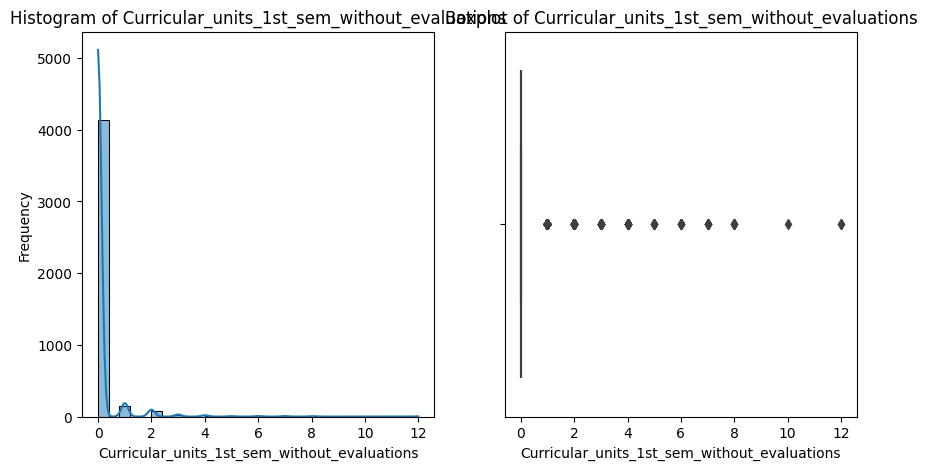

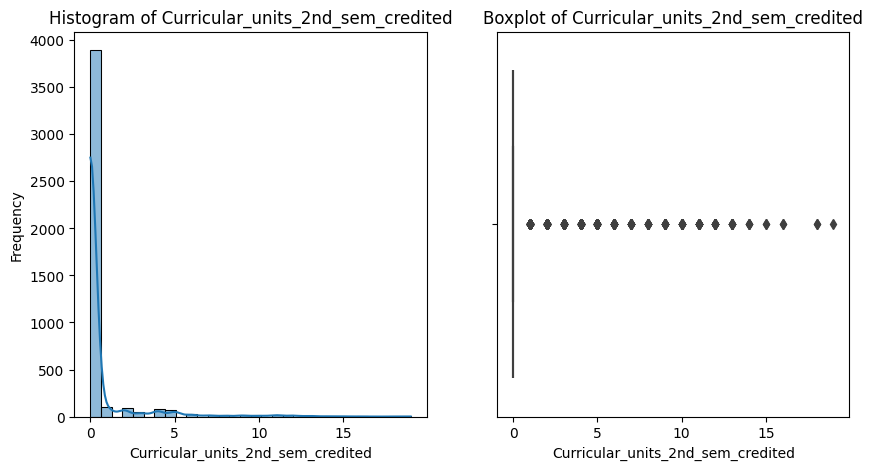

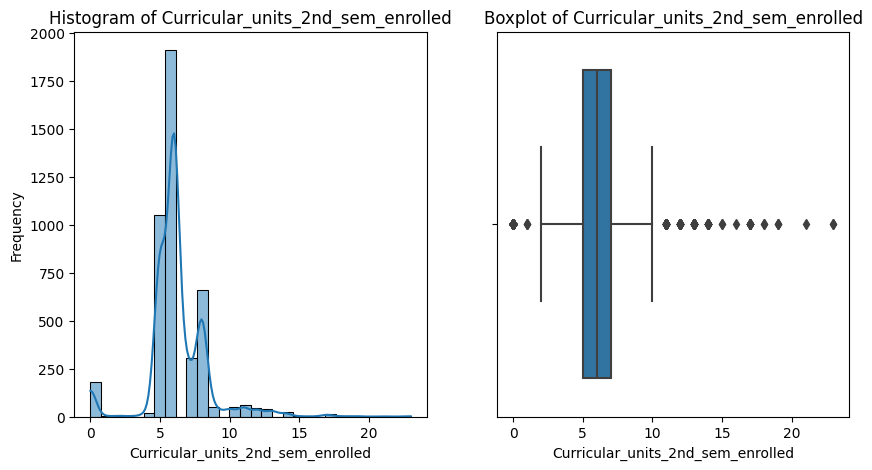

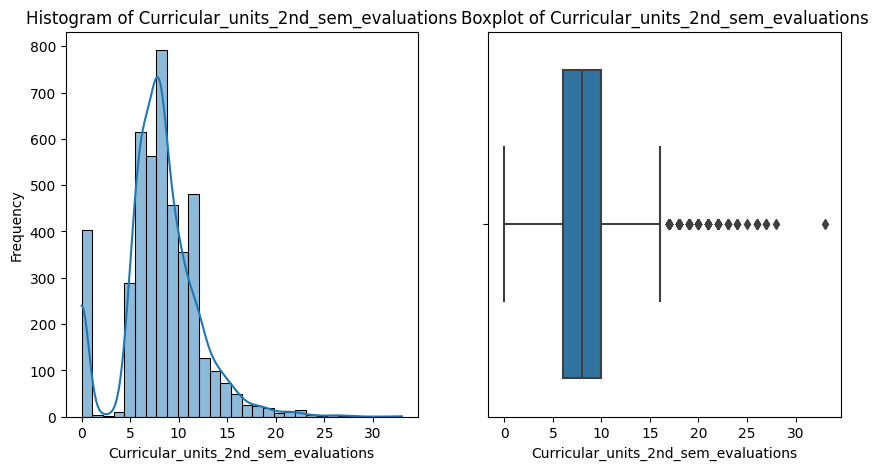

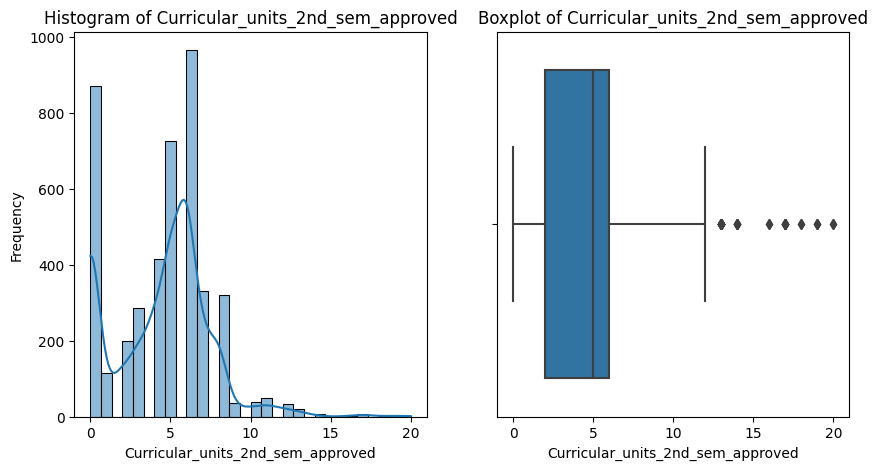

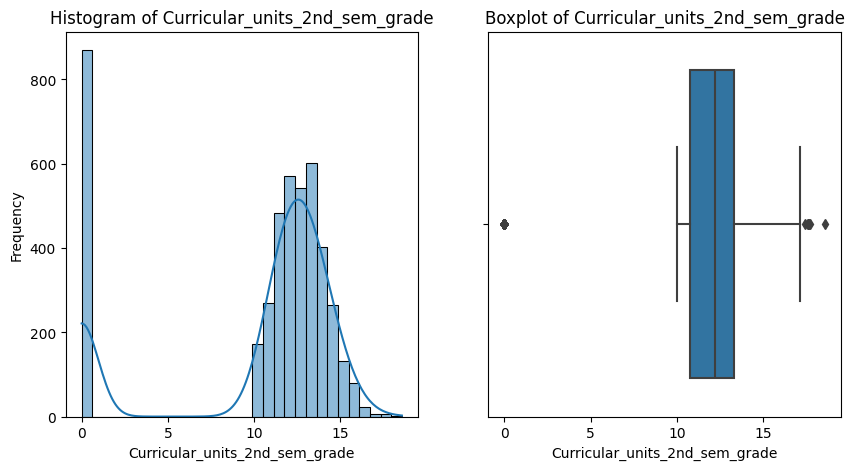

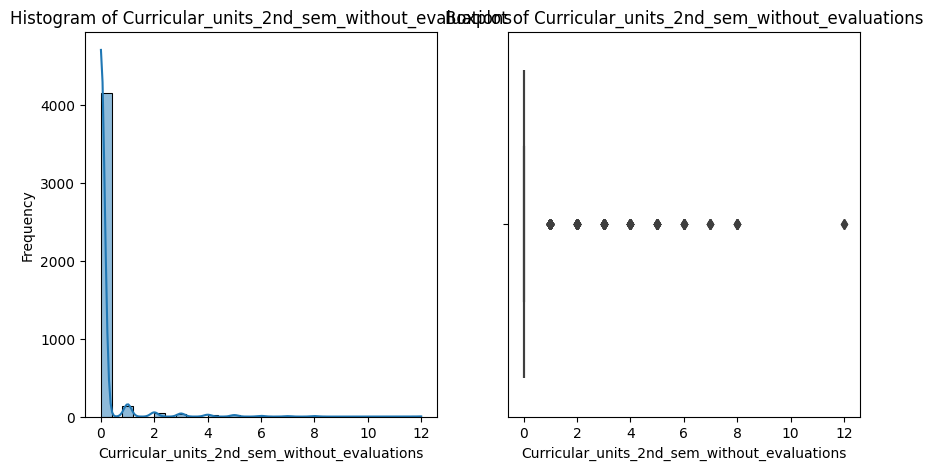

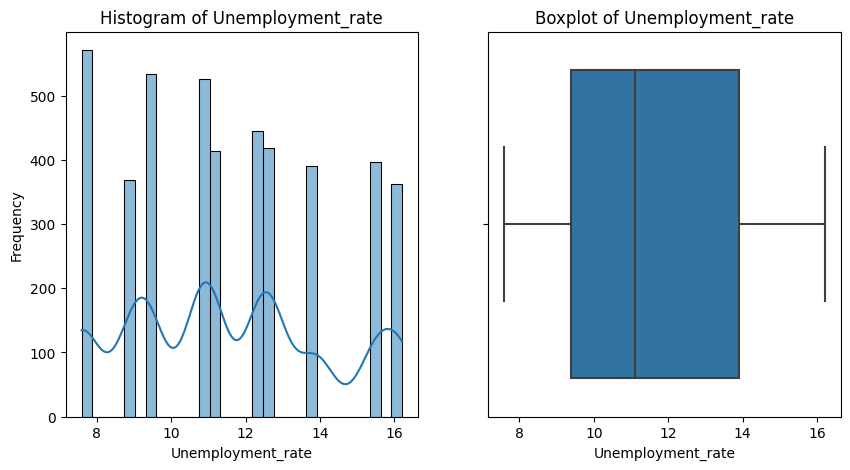

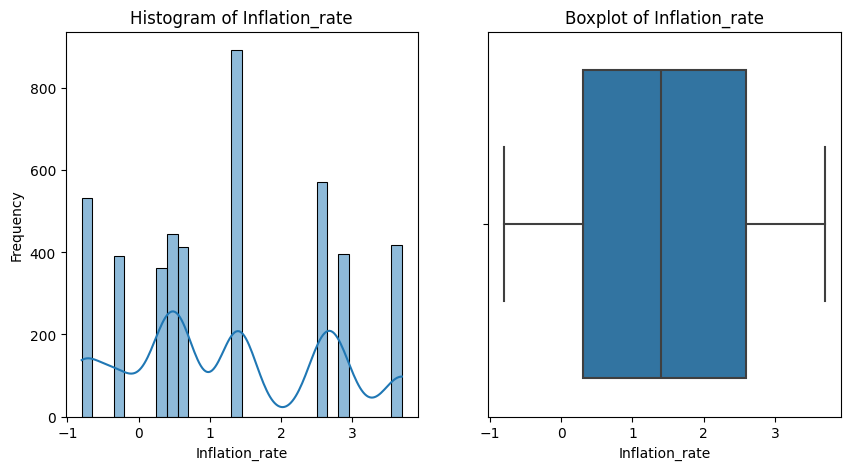

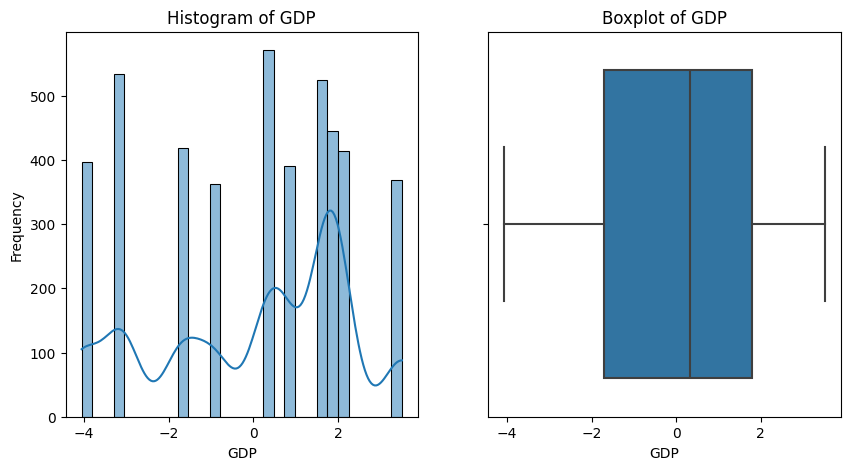

In [53]:
# Mengambil kolom bertipe float
float_columns = data2.select_dtypes(include=['int', 'float'])

# Membuat histogram dan boxplot untuk setiap kolom bertipe float
for col in float_columns.columns:
    plt.figure(figsize=(10, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data2[col], bins=30, kde=True) 
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data2[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout

### Persiapan Modeling

In [58]:
df = pd.read_csv('data.csv', sep=';') # Menggunakan data yang awal, karena numerik semua
df['Status'] = df['Status'].str.strip().str.lower()
df['Status'] = df['Status'].apply(lambda x: 'Dropout' if x == 'dropout' else 'Non-Dropout')
# 1. Label Encoding
df['Status'] = df['Status'].map({'Dropout': 1, 'Non-Dropout': 0})

# 2. Cek distribusi awal
print("Distribusi awal:")
print(df['Status'].value_counts())

# 3. Pisahkan mayoritas dan minoritas
df_majority = df[df['Status'] == 0]
df_minority = df[df['Status'] == 1]

# 4. Upsample minority
df_minority_upsampled = resample(
    df_minority,
    replace=True,                      # Sample with replacement
    n_samples=len(df_majority),        # Match majority class count
    random_state=42                    # Reproducibility
)

# 5. Gabungkan kembali
data_balanced = pd.concat([df_majority, df_minority_upsampled])

# 6. Shuffle agar acak
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 7. Cek distribusi hasil
print("\nDistribusi setelah upsampling:")
print(data_balanced['Status'].value_counts())

Distribusi awal:
Status
0    3003
1    1421
Name: count, dtype: int64

Distribusi setelah upsampling:
Status
0    3003
1    3003
Name: count, dtype: int64


In [59]:
data_balanced

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,43,1,9500,1,1,130.0,1,38,38,...,0,7,7,7,13.000000,0,13.9,-0.3,0.79,0
1,1,18,3,9670,1,1,119.0,1,38,38,...,0,6,6,0,0.000000,0,12.7,3.7,-1.70,1
2,2,43,1,8014,0,1,130.0,1,34,34,...,4,7,8,6,12.000000,0,9.4,-0.8,-3.12,1
3,1,1,3,9556,1,1,122.0,1,19,19,...,0,8,8,8,15.062500,0,12.4,0.5,1.79,0
4,1,1,1,171,1,1,163.0,1,1,1,...,0,0,0,0,0.000000,0,13.9,-0.3,0.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6001,1,1,1,9670,1,1,125.0,1,19,1,...,0,5,5,4,11.000000,0,9.4,-0.8,-3.12,1
6002,4,39,1,9500,1,1,133.1,1,1,19,...,0,8,0,0,0.000000,0,12.4,0.5,1.79,1
6003,1,17,1,9773,1,1,125.0,1,3,3,...,0,6,14,3,11.000000,0,13.9,-0.3,0.79,1
6004,1,17,1,9085,1,1,137.0,1,1,1,...,0,6,7,0,0.000000,0,16.2,0.3,-0.92,1


In [60]:
X = data_balanced.drop('Status', axis=1)
y = data_balanced['Status']

In [61]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Persiapan Training Ulang

In [75]:
X = data_balanced[important_feature_names]
y = data_balanced['Status']

# Split & train
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

## Modeling

In [62]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2', None]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                               param_grid_dt,
                               cv=5,  # Use cross-validation for robust evaluation
                               scoring='accuracy',
                               n_jobs=-1)  # Use all available cores
grid_search_dt.fit(X_train, y_train)

best_dt_grid = grid_search_dt.best_estimator_
print("Best parameters found by GridSearchCV:", grid_search_dt.best_params_)

/home/gede/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/gede/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/gede/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/gede/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Best parameters found by GridSearchCV: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}


### Training Ulang

In [78]:
param_grid_dt2 = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2', None]
}

grid_search_dt2 = GridSearchCV(DecisionTreeClassifier(random_state=42),
                               param_grid_dt2,
                               cv=5,  # Use cross-validation for robust evaluation
                               scoring='accuracy',
                               n_jobs=-1)  # Use all available cores
grid_search_dt2.fit(X_train, y_train)

best_dt_grid2 = grid_search_dt2.best_estimator_
print("Best parameters found by GridSearchCV:", grid_search_dt2.best_params_)

Best parameters found by GridSearchCV: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}


## Evaluation

In [68]:

y_pred_random = best_dt_grid.predict(X_test)
y_pred_proba_random = best_dt_grid.predict_proba(X_test)[:, 1] # Probabilitas untuk kelas positif

accuracy_random = accuracy_score(y_test, y_pred_random)
precision_random = precision_score(y_test, y_pred_random)
recall_random = recall_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random)
roc_auc_random = roc_auc_score(y_test, y_pred_proba_random)
cm_random = confusion_matrix(y_test, y_pred_random)

print(f"Accuracy with RandomizedSearchCV: {accuracy_random:.4f}")
print(f"Precision with RandomizedSearchCV: {precision_random:.4f}")
print(f"Recall with RandomizedSearchCV: {recall_random:.4f}")
print(f"F1-Score with RandomizedSearchCV: {f1_random:.4f}")
print(f"AUC-ROC with RandomizedSearchCV: {roc_auc_random:.4f}")


Accuracy with RandomizedSearchCV: 0.8960
Precision with RandomizedSearchCV: 0.8571
Recall with RandomizedSearchCV: 0.9479
F1-Score with RandomizedSearchCV: 0.9002
AUC-ROC with RandomizedSearchCV: 0.8965


### Evaluasi Ulang

In [79]:

y_pred_random = best_dt_grid2.predict(X_test)
y_pred_proba_random = best_dt_grid2.predict_proba(X_test)[:, 1] # Probabilitas untuk kelas positif

accuracy_random = accuracy_score(y_test, y_pred_random)
precision_random = precision_score(y_test, y_pred_random)
recall_random = recall_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random)
roc_auc_random = roc_auc_score(y_test, y_pred_proba_random)
cm_random = confusion_matrix(y_test, y_pred_random)

print(f"Accuracy with RandomizedSearchCV: {accuracy_random:.4f}")
print(f"Precision with RandomizedSearchCV: {precision_random:.4f}")
print(f"Recall with RandomizedSearchCV: {recall_random:.4f}")
print(f"F1-Score with RandomizedSearchCV: {f1_random:.4f}")
print(f"AUC-ROC with RandomizedSearchCV: {roc_auc_random:.4f}")


Accuracy with RandomizedSearchCV: 0.8993
Precision with RandomizedSearchCV: 0.8810
Recall with RandomizedSearchCV: 0.9210
F1-Score with RandomizedSearchCV: 0.9006
AUC-ROC with RandomizedSearchCV: 0.9003


## Mencari Feature Importance

                                         feature  importance
30             Curricular_units_2nd_sem_approved    0.132924
16                       Tuition_fees_up_to_date    0.118758
24             Curricular_units_1st_sem_approved    0.118305
31                Curricular_units_2nd_sem_grade    0.064651
12                               Admission_grade    0.059954
25                Curricular_units_1st_sem_grade    0.048099
29          Curricular_units_2nd_sem_evaluations    0.040202
1                               Application_mode    0.035317
10                            Mothers_occupation    0.034392
6                   Previous_qualification_grade    0.032952
23          Curricular_units_1st_sem_evaluations    0.025604
11                            Fathers_occupation    0.025169
3                                         Course    0.024799
9                          Fathers_qualification    0.024439
35                                           GDP    0.023601
19                      

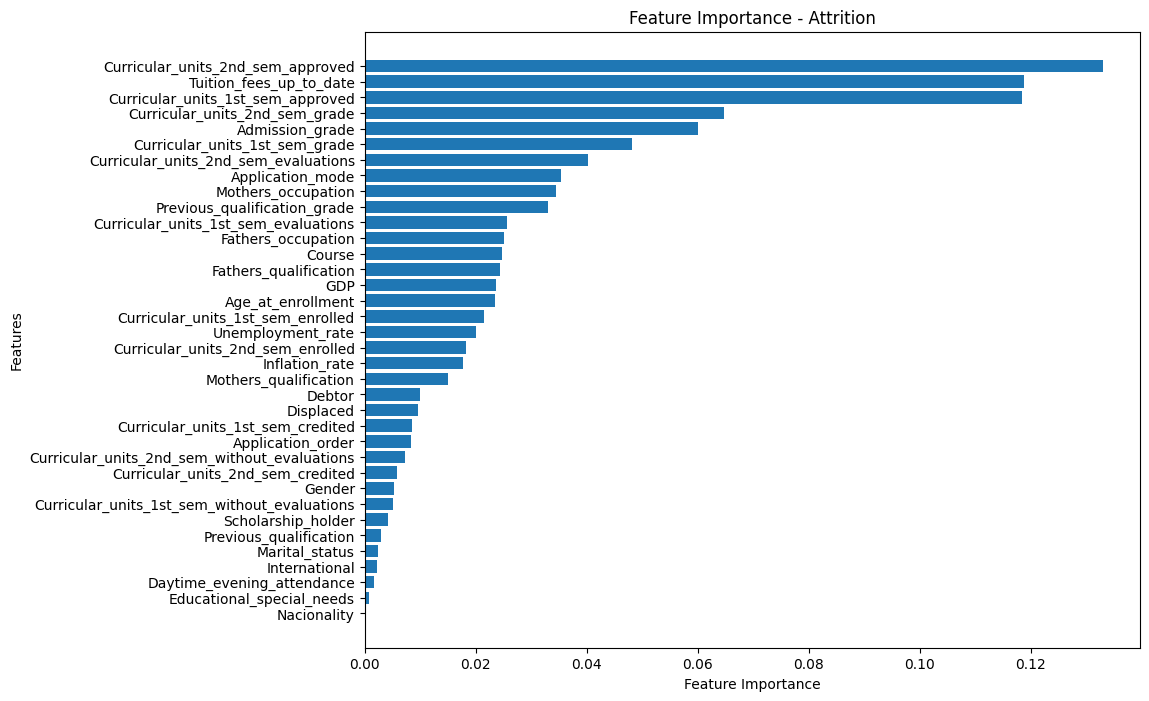

In [66]:
# Ambil feature importance dari model Decission Tree
importances = best_dt_grid.feature_importances_

# Masukkan ke DataFrame untuk dirapikan
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Urutkan dari yang paling penting
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
top_importances = pd.Series(best_dt_grid.feature_importances_, index=X.columns)
top_features = top_importances.sort_values(ascending=False).head(10)

# Tampilkan
print(feature_importance_df)

# Bikin plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Attrition')
plt.gca().invert_yaxis()  
plt.show()


## Inference

In [80]:
with open('model.pkl', 'wb') as model_file:
    pickle.dump(best_dt_grid2, model_file)

In [67]:
important_feature_names = top_features.index.tolist()
important_feature_names

['Curricular_units_2nd_sem_approved',
 'Tuition_fees_up_to_date',
 'Curricular_units_1st_sem_approved',
 'Curricular_units_2nd_sem_grade',
 'Admission_grade',
 'Curricular_units_1st_sem_grade',
 'Curricular_units_2nd_sem_evaluations',
 'Application_mode',
 'Mothers_occupation',
 'Previous_qualification_grade']

In [84]:
import pandas as pd

# 1. Data input user sebagai dictionary
user_input_dict = {
    'Curricular_units_2nd_sem_approved': 5,
    'Tuition_fees_up_to_date': 1,
    'Curricular_units_1st_sem_approved': 6,
    'Curricular_units_2nd_sem_grade': 12.5,
    'Admission_grade': 145,
    'Curricular_units_1st_sem_grade': 13.7,
    'Curricular_units_2nd_sem_evaluations': 6,
    'Application_mode': 1,
    'Mothers_occupation': 4,
    'Previous_qualification_grade': 150
}

# 3. Buat DataFrame
input_df = pd.DataFrame([user_input_dict])

# 4. Pastikan urutan kolom sesuai saat training
input_df = input_df[important_feature_names]

# 5. Prediksi
prediction = best_dt_grid2.predict(input_df)[0]

# 6. Interpretasi hasil
label = 'Dropout' if prediction == 1 else 'Non-Dropout'
print("Hasil Prediksi:", label)


Hasil Prediksi: Non-Dropout
